In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    r"C:\Users\Prasad\Desktop\secure-bank-fraud-ml\data\paysim_model_ready_full.csv"
)

df.sort_values('day', inplace=True)
df.reset_index(drop=True, inplace=True)


In [3]:
X = df.drop(columns=['isFraud'])
y = df['isFraud']

n = len(df)

train_end = int(0.70 * n)
val_end   = int(0.85 * n)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val     = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test   = X.iloc[val_end:], y.iloc[val_end:]


In [5]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
     callbacks=[lgb.log_evaluation(period=10)]
)


[LightGBM] [Info] Number of positive: 3537, number of negative: 4450297
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041262 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2343
[LightGBM] [Info] Number of data points in the train set: 4453834, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[10]	valid_0's auc: 1	valid_0's binary_logloss: 0.3581
[20]	valid_0's auc: 1	valid_0's binary_logloss: 0.200983
[30]	valid_0's auc: 1	valid_0's binary_logloss: 0.116966
[40]	valid_0's auc: 1	valid_0's binary_logloss: 0.0693997
[50]	valid_0's auc: 1	valid_0's binary_logloss: 0.0415493
[60]	valid_0's auc: 1	valid_0's binary_logloss: 0.0250412
[70]	valid_0's auc: 1	valid_0's binary_logloss: 0.0151628
[80]	valid_0's auc: 1	valid_0's binary

LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
               learning_rate=0.05, n_estimators=300, n_jobs=-1, num_leaves=64,
               random_state=42, subsample=0.8)

In [6]:
from sklearn.metrics import classification_report, roc_auc_score

y_test_pred = lgb_model.predict(X_test)
y_test_prob = lgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, y_test_prob))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    950283
           1       1.00      1.00      1.00      4110

    accuracy                           1.00    954393
   macro avg       1.00      1.00      1.00    954393
weighted avg       1.00      1.00      1.00    954393

Test ROC-AUC: 0.9999999247246907


In [7]:
threshold = 0.2
y_adj_pred = (y_test_prob >= threshold).astype(int)

print(classification_report(y_test, y_adj_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    950283
           1       1.00      1.00      1.00      4110

    accuracy                           1.00    954393
   macro avg       1.00      1.00      1.00    954393
weighted avg       1.00      1.00      1.00    954393



In [8]:
import pandas as pd

imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)

imp.head(10)


,feature,importance
4,newbalanceDest,3286
3,oldbalanceDest,2674
6,hour_of_day,2376
0,amount,2287
12,balance_error,2064
9,amount_to_balance_ratio,1751
7,day,1598
1,oldbalanceOrg,664
2,newbalanceOrig,582
11,balance_diff_org,486


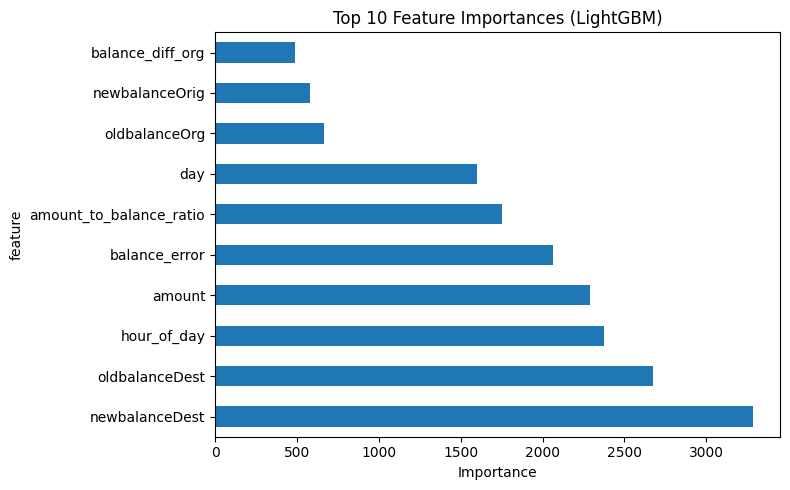

In [9]:
import matplotlib.pyplot as plt

imp.head(10).plot(
    x='feature',
    y='importance',
    kind='barh',
    figsize=(8,5),
    legend=False
)
plt.title("Top 10 Feature Importances (LightGBM)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [11]:
import joblib

joblib.dump(
    lgb_model,
    r"C:\Users\Prasad\Desktop\secure-bank-fraud-ml\models\fraud_lgbm_final.pkl"
)


['C:\\Users\\Prasad\\Desktop\\secure-bank-fraud-ml\\models\\fraud_lgbm_final.pkl']